# 02 — EDA do Clima no Estado de São Paulo

Este notebook realiza a Análise Exploratória de Dados (EDA) do dataset meteorológico horário já recortado para o **estado de São Paulo (SP)**.

A proposta desta EDA é construir uma narrativa climática para apoiar o projeto de Big Data:

- entender a qualidade dos dados;
- analisar a distribuição espacial das estações meteorológicas;
- comparar regiões do estado de São Paulo;
- observar diferenças entre litoral, serra, áreas urbanas e interior;
- investigar relações entre temperatura, umidade, precipitação, altitude e localização;
- preparar os principais insights que justificam a etapa de modelagem preditiva.

O objetivo final do projeto é prever:

- a temperatura de amanhã;
- a temperatura média da próxima semana.

## 1. Inicialização da SparkSession

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("EDA_Clima_SP_SparkSQL")
    .getOrCreate()
)

spark

## 2. Importação das bibliotecas

In [3]:
from pyspark.sql.functions import (
    col,
    when,
    regexp_replace,
    regexp_extract,
    to_date,
    year,
    month,
    dayofmonth,
    count,
    avg,
    min,
    max,
    stddev,
    round,
    lit,
    sqrt,
    pow,
    sin,
    cos,
    asin,
    radians
)

from pyspark.sql.functions import sum as spark_sum
from pyspark.sql.functions import corr

import unicodedata
import re
import matplotlib.pyplot as plt

## 3. Carregamento da base Parquet

A base utilizada neste notebook já está em formato Parquet e já foi previamente filtrada para o estado de São Paulo.

Por isso, as próximas análises consideram diretamente o recorte paulista, sem necessidade de novo filtro por estado.

In [4]:
parquet_path = "/home/jovyan/work/data/processed/weather_sp_parquet"

df_raw = spark.read.parquet(parquet_path)

df_raw.createOrReplaceTempView("weather_raw")

spark.sql("""
    SELECT *
    FROM weather_raw
    LIMIT 5
""").show(truncate=False)

+------+----------+-------------------+--------------------------------+-----------------------------------------------------+-----------------------------------------------+------------------------------------------------+-----------------------+--------------------------------------------+------------------------------------+------------------------------------------+------------------------------------------+------------------------------------------------+------------------------------------------------+----------------------------------------+----------------------------------------+-----------------------------------+------------------------------------+--------------------------+-------------------------------+------+-----+--------+------------+------------+------------+------+
|index |Data      |Hora               |PRECIPITAÇÃO TOTAL, HORÁRIO (mm)|PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)|PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)|PRESSÃO ATMOSFERICA MIN. NA HO

## 4. Estrutura inicial do dataset

In [5]:
df_raw.printSchema()

print(f"Quantidade de colunas: {len(df_raw.columns)}")

print("\nColunas originais:")
for c in df_raw.columns:
    print("-", c)

root
 |-- index: integer (nullable = true)
 |-- Data: date (nullable = true)
 |-- Hora: timestamp (nullable = true)
 |-- PRECIPITAÇÃO TOTAL, HORÁRIO (mm): double (nullable = true)
 |-- PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB): double (nullable = true)
 |-- PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB): double (nullable = true)
 |-- PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB): double (nullable = true)
 |-- RADIACAO GLOBAL (Kj/m²): integer (nullable = true)
 |-- TEMPERATURA DO AR - BULBO SECO, HORARIA (°C): double (nullable = true)
 |-- TEMPERATURA DO PONTO DE ORVALHO (°C): double (nullable = true)
 |-- TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C): double (nullable = true)
 |-- UMIDADE REL. MAX. NA HORA ANT. (AUT) (%): integer (nullable = t

## 5. Normalização dos nomes das colunas

In [6]:
def normalizar_nome_coluna(nome):
    nome = nome.strip()
    nome = unicodedata.normalize("NFKD", nome)
    nome = nome.encode("ASCII", "ignore").decode("utf-8")
    nome = nome.lower()
    nome = re.sub(r"[^a-z0-9]+", "_", nome)
    nome = re.sub(r"_+", "_", nome)
    nome = nome.strip("_")
    return nome

colunas_normalizadas = [normalizar_nome_coluna(c) for c in df_raw.columns]
df = df_raw.toDF(*colunas_normalizadas)

df.columns

['index',
 'data',
 'hora',
 'precipitacao_total_horario_mm',
 'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
 'pressao_atmosferica_max_na_hora_ant_aut_mb',
 'pressao_atmosferica_min_na_hora_ant_aut_mb',
 'radiacao_global_kj_m2',
 'temperatura_do_ar_bulbo_seco_horaria_c',
 'temperatura_do_ponto_de_orvalho_c',
 'temperatura_maxima_na_hora_ant_aut_c',
 'temperatura_minima_na_hora_ant_aut_c',
 'temperatura_orvalho_max_na_hora_ant_aut_c',
 'temperatura_orvalho_min_na_hora_ant_aut_c',
 'umidade_rel_max_na_hora_ant_aut',
 'umidade_rel_min_na_hora_ant_aut',
 'umidade_relativa_do_ar_horaria',
 'vento_direcao_horaria_gr_gr',
 'vento_rajada_maxima_m_s',
 'vento_velocidade_horaria_m_s',
 'region',
 'state',
 'station',
 'station_code',
 'latitude',
 'longitude',
 'height']

## 6. Renomeação das variáveis principais

In [7]:
mapa_renomeacao = {
    "precipitacao_total_horario_mm": "precipitacao",
    "pressao_atmosferica_ao_nivel_da_estacao_horaria_mb": "pressao",
    "pressao_atmosferica_max_na_hora_ant_aut_mb": "pressao_maxima",
    "pressao_atmosferica_min_na_hora_ant_aut_mb": "pressao_minima",
    "radiacao_global_kj_m2": "radiacao",
    "temperatura_do_ar_bulbo_seco_horaria_c": "temperatura",
    "temperatura_maxima_na_hora_ant_aut_c": "temperatura_maxima",
    "temperatura_minima_na_hora_ant_aut_c": "temperatura_minima",
    "umidade_relativa_do_ar_horaria": "umidade",
    "umidade_rel_max_na_hora_ant_aut": "umidade_maxima",
    "umidade_rel_min_na_hora_ant_aut": "umidade_minima",
    "vento_direcao_horaria_gr_gr": "direcao_vento",
    "vento_rajada_maxima_m_s": "rajada_vento",
    "vento_velocidade_horaria_m_s": "velocidade_vento",
    "height": "altitude"
}

for antiga, nova in mapa_renomeacao.items():
    if antiga in df.columns:
        df = df.withColumnRenamed(antiga, nova)

df.printSchema()

root
 |-- index: integer (nullable = true)
 |-- data: date (nullable = true)
 |-- hora: timestamp (nullable = true)
 |-- precipitacao: double (nullable = true)
 |-- pressao: double (nullable = true)
 |-- pressao_maxima: double (nullable = true)
 |-- pressao_minima: double (nullable = true)
 |-- radiacao: integer (nullable = true)
 |-- temperatura: double (nullable = true)
 |-- temperatura_do_ponto_de_orvalho_c: double (nullable = true)
 |-- temperatura_maxima: double (nullable = true)
 |-- temperatura_minima: double (nullable = true)
 |-- temperatura_orvalho_max_na_hora_ant_aut_c: double (nullable = true)
 |-- temperatura_orvalho_min_na_hora_ant_aut_c: double (nullable = true)
 |-- umidade_maxima: integer (nullable = true)
 |-- umidade_minima: integer (nullable = true)
 |-- umidade: integer (nullable = true)
 |-- direcao_vento: integer (nullable = true)
 |-- rajada_vento: double (nullable = true)
 |-- velocidade_vento: double (nullable = true)
 |-- region: string (nullable = true)
 |--

## 7. Conversão das variáveis numéricas

In [8]:
colunas_numericas = [
    "latitude",
    "longitude",
    "altitude",
    "temperatura",
    "temperatura_maxima",
    "temperatura_minima",
    "umidade",
    "umidade_maxima",
    "umidade_minima",
    "pressao",
    "pressao_maxima",
    "pressao_minima",
    "precipitacao",
    "radiacao",
    "velocidade_vento",
    "rajada_vento",
    "direcao_vento"
]

colunas_numericas = [c for c in colunas_numericas if c in df.columns]

for c in colunas_numericas:
    df = df.withColumn(
        c,
        regexp_replace(col(c).cast("string"), ",", ".").cast("double")
    )

## 8. Criação das variáveis temporais

In [9]:
df = df.withColumn(
    "data_formatada",
    when(
        to_date(col("data"), "yyyy-MM-dd").isNotNull(),
        to_date(col("data"), "yyyy-MM-dd")
    ).otherwise(
        to_date(col("data"), "dd/MM/yyyy")
    )
)

df = (
    df
    .withColumn("ano", year(col("data_formatada")))
    .withColumn("mes", month(col("data_formatada")))
    .withColumn("dia", dayofmonth(col("data_formatada")))
    .withColumn("hora_num", regexp_extract(col("hora").cast("string"), r"(\d{2})", 1).cast("int"))
)

## 9. Recorte do estado de São Paulo

In [10]:
df_sp = df

df_sp.createOrReplaceTempView("weather_sp_raw")

spark.sql("""
    SELECT
        state,
        COUNT(*) AS total_registros,
        COUNT(DISTINCT station_code) AS total_estacoes,
        MIN(data_formatada) AS data_inicial,
        MAX(data_formatada) AS data_final
    FROM weather_sp_raw
    GROUP BY state
    ORDER BY state
""").show(truncate=False)

+-----+---------------+--------------+------------+----------+
|state|total_registros|total_estacoes|data_inicial|data_final|
+-----+---------------+--------------+------------+----------+
|SP   |4288560        |43            |2001-08-30  |2021-04-30|
+-----+---------------+--------------+------------+----------+



## 10. Tratamento de valores sentinela para EDA

In [11]:
df_sp_tratado = df_sp

for c in colunas_numericas:
    if c in df_sp_tratado.columns:
        df_sp_tratado = df_sp_tratado.withColumn(
            c,
            when(col(c) <= -999, None).otherwise(col(c))
        )

df_sp_tratado.createOrReplaceTempView("weather_sp")

## 11. Dimensão da base de São Paulo

In [12]:
spark.sql("""
    SELECT
        COUNT(*) AS total_linhas,
        COUNT(DISTINCT station_code) AS total_estacoes,
        COUNT(DISTINCT station) AS total_cidades_ou_estacoes,
        MIN(data_formatada) AS data_inicial,
        MAX(data_formatada) AS data_final
    FROM weather_sp
""").show(truncate=False)

+------------+--------------+-------------------------+------------+----------+
|total_linhas|total_estacoes|total_cidades_ou_estacoes|data_inicial|data_final|
+------------+--------------+-------------------------+------------+----------+
|4288560     |43            |43                       |2001-08-30  |2021-04-30|
+------------+--------------+-------------------------+------------+----------+



## 12. Qualidade dos dados: percentual de nulos

In [13]:
df_sp_tratado.createOrReplaceTempView("weather_sp")

total_sp = spark.sql("""
    SELECT COUNT(*) AS total
    FROM weather_sp
""").collect()[0]["total"]

expressoes_sql = []

for c in df_sp_tratado.columns:
    expressoes_sql.append(
        f"""
        ROUND(
            SUM(CASE WHEN `{c}` IS NULL THEN 1 ELSE 0 END) / {total_sp} * 100,
            2
        ) AS `{c}`
        """
    )

query_nulos = f"""
    SELECT
        {",".join(expressoes_sql)}
    FROM weather_sp
"""

df_percentual_nulos = spark.sql(query_nulos)

df_percentual_nulos.show(truncate=False)

+-----+----+----+------------+-------+--------------+--------------+--------+-----------+---------------------------------+------------------+------------------+-----------------------------------------+-----------------------------------------+--------------+--------------+-------+-------------+------------+----------------+------+-----+-------+------------+--------+---------+--------+--------------+---+---+---+--------+
|index|data|hora|precipitacao|pressao|pressao_maxima|pressao_minima|radiacao|temperatura|temperatura_do_ponto_de_orvalho_c|temperatura_maxima|temperatura_minima|temperatura_orvalho_max_na_hora_ant_aut_c|temperatura_orvalho_min_na_hora_ant_aut_c|umidade_maxima|umidade_minima|umidade|direcao_vento|rajada_vento|velocidade_vento|region|state|station|station_code|latitude|longitude|altitude|data_formatada|ano|mes|dia|hora_num|
+-----+----+----+------------+-------+--------------+--------------+--------+-----------+---------------------------------+------------------+------

## 13. Cobertura temporal por ano

In [14]:
import plotly.graph_objects as go

registros_ano = spark.sql("""
    SELECT
        ano,
        COUNT(*) AS total_registros,
        COUNT(DISTINCT station_code) AS total_estacoes
    FROM weather_sp
    WHERE ano IS NOT NULL
    GROUP BY ano
    ORDER BY ano
""")

registros_ano.show(100, truncate=False)

dados = registros_ano.collect()

anos = [linha["ano"] for linha in dados]
totais = [linha["total_registros"] for linha in dados]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=anos,
    y=totais,
    mode="lines+markers",
    name="Total de registros"
))

fig.update_layout(
    title="Quantidade de registros por ano - SP",
    xaxis_title="Ano",
    yaxis_title="Total de registros",
    template="plotly_white"
)

fig.show()

+----+---------------+--------------+
|ano |total_registros|total_estacoes|
+----+---------------+--------------+
|2001|2976           |1             |
|2002|16296          |3             |
|2003|34224          |4             |
|2004|35136          |4             |
|2005|35040          |4             |
|2006|70152          |17            |
|2007|167784         |25            |
|2008|240144         |29            |
|2009|254040         |29            |
|2010|258744         |30            |
|2011|269472         |31            |
|2012|272304         |31            |
|2013|271560         |31            |
|2014|271560         |31            |
|2015|271560         |31            |
|2016|275304         |33            |
|2017|319752         |40            |
|2018|357432         |41            |
|2019|363528         |42            |
|2020|377712         |43            |
|2021|123840         |43            |
+----+---------------+--------------+



## 14. Lista de estações meteorológicas em São Paulo

In [15]:
estacoes_sp = spark.sql("""
    SELECT DISTINCT
        station,
        station_code,
        latitude,
        longitude,
        altitude
    FROM weather_sp
    ORDER BY station
""")

estacoes_sp.show(300, truncate=False)

+----------------------+------------+------------+------------+--------+
|station               |station_code|latitude    |longitude   |altitude|
+----------------------+------------+------------+------------+--------+
|ARIRANHA              |A736        |-21.13305554|-48.84027777|525.0   |
|ARIRANHA              |A736        |-21.13305554|-48.84055555|525.44  |
|AVARE                 |A725        |-23.09972221|-48.94555555|775.0   |
|AVARE                 |A725        |-23.10166666|-48.9411111 |776.36  |
|BARRA BONITA          |A741        |-22.4711111 |-48.5575    |533.68  |
|BARRA BONITA          |A741        |-22.37083332|-48.55722222|544.0   |
|BARRA DO TURVO        |A746        |-24.96277777|-48.41638888|659.89  |
|BARRA DO TURVO        |A746        |-24.96305555|-48.41638888|667.0   |
|BARRETOS              |A748        |-20.55916666|-48.54499999|534.36  |
|BARRETOS              |A748        |-20.55888888|-48.54472221|533.0   |
|BARUERI               |A755        |-23.52388888|-

## 15. Classificação geográfica das estações

In [16]:
df_sp_geo = (
    df_sp_tratado
    .withColumn(
        "faixa_altitude",
        when(col("altitude").isNull(), "sem_info")
        .when(col("altitude") < 300, "baixa_altitude")
        .when(col("altitude") < 700, "media_altitude")
        .otherwise("alta_altitude")
    )
    .withColumn(
        "macro_regiao_sp",
        when((col("longitude") <= -48.5) & (col("latitude") <= -23.5), "sul_sudoeste")
        .when((col("longitude") <= -48.5) & (col("latitude") > -23.5), "oeste_noroeste")
        .when((col("longitude") > -47.0) & (col("latitude") <= -23.5), "leste_sudeste")
        .when((col("longitude") > -47.0) & (col("latitude") > -23.5), "nordeste_vale")
        .otherwise("centro_metropolitana")
    )
    .withColumn(
        "tipo_area",
        when((col("altitude") < 100) & (col("longitude") > -47.0), "litoral")
        .when(col("altitude") >= 700, "serra_altitude")
        .when(
            col("station").rlike("(?i)SAO PAULO|SÃO PAULO|BARUERI|GUARULHOS|OSASCO|ABC|SANTO ANDRE|SANTO ANDRÉ|SAO BERNARDO|SÃO BERNARDO"),
            "urbano_metropolitano"
        )
        .otherwise("interior")
    )
)

df_sp_geo.createOrReplaceTempView("weather_sp_geo")

spark.sql("""
    SELECT
        macro_regiao_sp,
        tipo_area,
        faixa_altitude,
        COUNT(*) AS total_registros,
        COUNT(DISTINCT station_code) AS total_estacoes
    FROM weather_sp_geo
    GROUP BY macro_regiao_sp, tipo_area, faixa_altitude
    ORDER BY macro_regiao_sp, tipo_area, faixa_altitude
""").show(100, truncate=False)

+--------------------+--------------+--------------+---------------+--------------+
|macro_regiao_sp     |tipo_area     |faixa_altitude|total_registros|total_estacoes|
+--------------------+--------------+--------------+---------------+--------------+
|centro_metropolitana|interior      |baixa_altitude|166584         |2             |
|centro_metropolitana|interior      |media_altitude|759528         |8             |
|centro_metropolitana|serra_altitude|alta_altitude |431472         |4             |
|leste_sudeste       |litoral       |baixa_altitude|68016          |2             |
|leste_sudeste       |serra_altitude|alta_altitude |133728         |3             |
|nordeste_vale       |interior      |media_altitude|275064         |3             |
|nordeste_vale       |serra_altitude|alta_altitude |427176         |4             |
|oeste_noroeste      |interior      |media_altitude|1737408        |16            |
|oeste_noroeste      |serra_altitude|alta_altitude |148464         |2       

## 16. Quantidade de estações por tipo de área

+--------------+--------------+---------------+
|tipo_area     |total_estacoes|total_registros|
+--------------+--------------+---------------+
|interior      |29            |2938584        |
|serra_altitude|14            |1281960        |
|litoral       |2             |68016          |
+--------------+--------------+---------------+



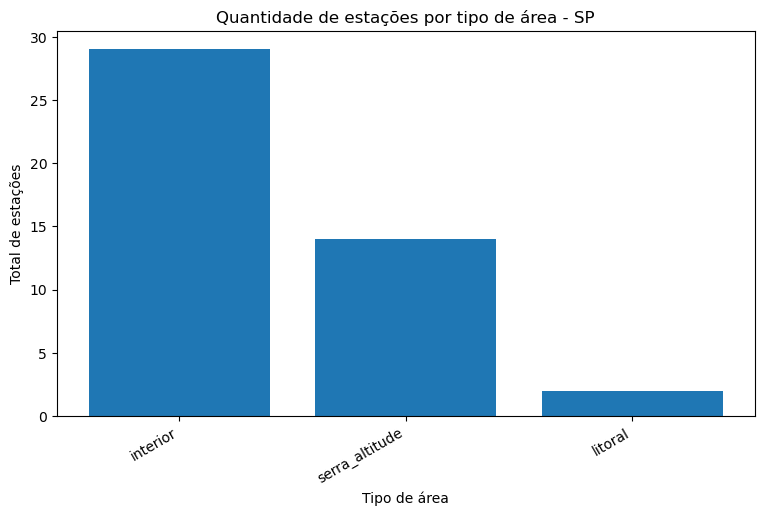

In [17]:
estacoes_tipo_area = spark.sql("""
    SELECT
        tipo_area,
        COUNT(DISTINCT station_code) AS total_estacoes,
        COUNT(*) AS total_registros
    FROM weather_sp_geo
    GROUP BY tipo_area
    ORDER BY total_estacoes DESC
""")

estacoes_tipo_area.show(truncate=False)

dados = estacoes_tipo_area.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(dados["tipo_area"], dados["total_estacoes"])
plt.title("Quantidade de estações por tipo de área - SP")
plt.xlabel("Tipo de área")
plt.ylabel("Total de estações")
plt.xticks(rotation=30, ha="right")
plt.show()

## 17. Temperatura média por tipo de área

+--------------+-----------------+------------------+------------------+------------------+-----------------+
|tipo_area     |temperatura_media|temperatura_minima|temperatura_maxima|desvio_temperatura|registros_validos|
+--------------+-----------------+------------------+------------------+------------------+-----------------+
|serra_altitude|19.62            |-51.4             |42.2              |6.97              |1147015          |
|interior      |22.3             |-3.6              |43.3              |5.44              |2660061          |
|litoral       |23.54            |11.4              |39.6              |3.73              |51787            |
+--------------+-----------------+------------------+------------------+------------------+-----------------+



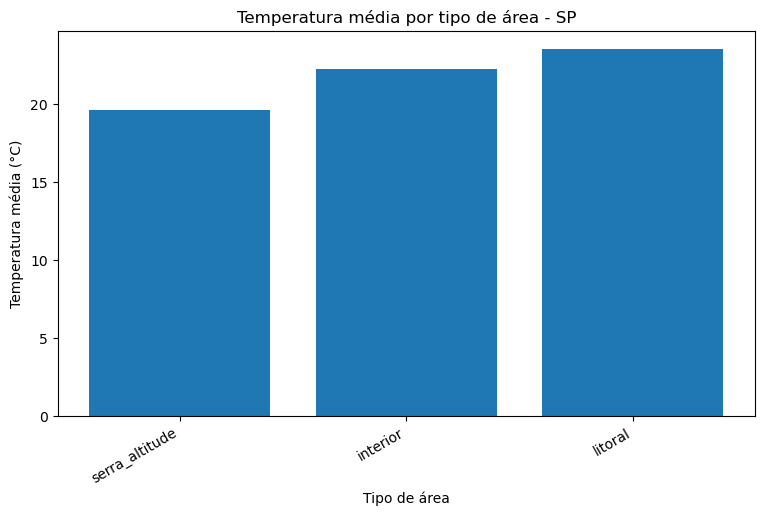

In [18]:
temp_tipo_area = spark.sql("""
    SELECT
        tipo_area,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(MIN(temperatura), 2) AS temperatura_minima,
        ROUND(MAX(temperatura), 2) AS temperatura_maxima,
        ROUND(STDDEV(temperatura), 2) AS desvio_temperatura,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
    GROUP BY tipo_area
    ORDER BY temperatura_media
""")

temp_tipo_area.show(truncate=False)

dados = temp_tipo_area.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(dados["tipo_area"], dados["temperatura_media"])
plt.title("Temperatura média por tipo de área - SP")
plt.xlabel("Tipo de área")
plt.ylabel("Temperatura média (°C)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 18. Temperatura média por macro região de São Paulo

+--------------------+-----------------+------------------+------------------+------------------+--------------+
|macro_regiao_sp     |temperatura_media|temperatura_minima|temperatura_maxima|desvio_temperatura|total_estacoes|
+--------------------+-----------------+------------------+------------------+------------------+--------------+
|sul_sudoeste        |16.08            |-51.4             |36.8              |14.27             |2             |
|nordeste_vale       |19.42            |-3.2              |38.9              |5.49              |7             |
|leste_sudeste       |20.99            |2.2               |39.6              |4.72              |5             |
|centro_metropolitana|21.3             |-3.6              |42.0              |5.11              |13            |
|oeste_noroeste      |22.93            |-3.6              |43.3              |5.37              |17            |
+--------------------+-----------------+------------------+------------------+------------------

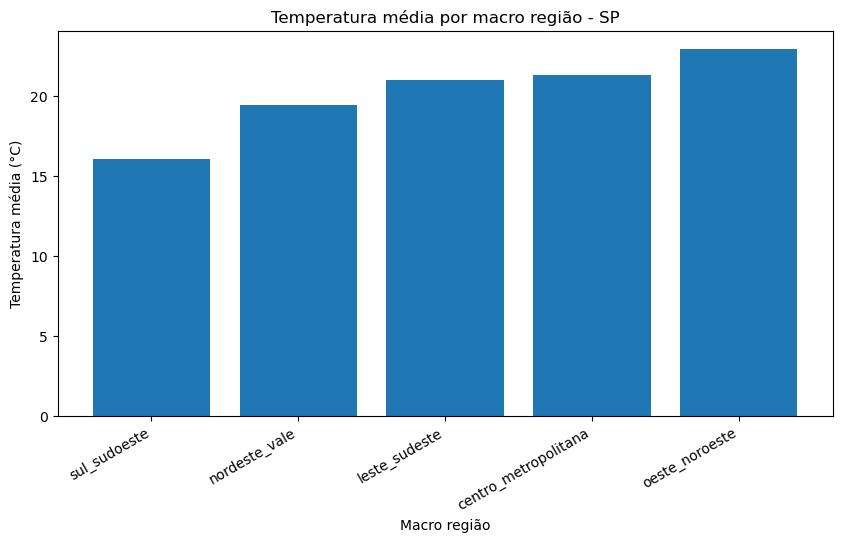

In [19]:
temp_macro = spark.sql("""
    SELECT
        macro_regiao_sp,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(MIN(temperatura), 2) AS temperatura_minima,
        ROUND(MAX(temperatura), 2) AS temperatura_maxima,
        ROUND(STDDEV(temperatura), 2) AS desvio_temperatura,
        COUNT(DISTINCT station_code) AS total_estacoes
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
    GROUP BY macro_regiao_sp
    ORDER BY temperatura_media
""")

temp_macro.show(truncate=False)

dados = temp_macro.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(dados["macro_regiao_sp"], dados["temperatura_media"])
plt.title("Temperatura média por macro região - SP")
plt.xlabel("Macro região")
plt.ylabel("Temperatura média (°C)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 19. Temperatura média por faixa de altitude

+--------------+--------------+-----------------+------------------+------------------+--------------+
|faixa_altitude|altitude_media|temperatura_media|temperatura_minima|temperatura_maxima|total_estacoes|
+--------------+--------------+-----------------+------------------+------------------+--------------+
|baixa_altitude|10.02         |22.15            |1.2               |42.0              |4             |
|media_altitude|528.98        |22.34            |-3.6              |43.3              |27            |
|alta_altitude |909.61        |19.62            |-51.4             |42.2              |14            |
+--------------+--------------+-----------------+------------------+------------------+--------------+



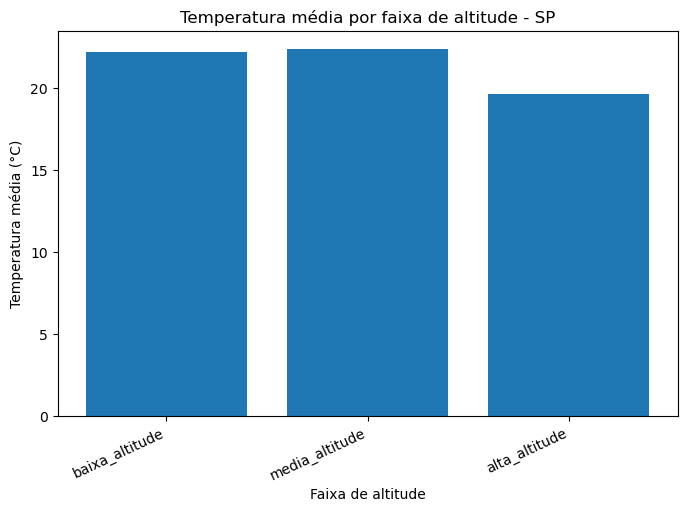

In [20]:
temp_altitude = spark.sql("""
    SELECT
        faixa_altitude,
        ROUND(AVG(altitude), 2) AS altitude_media,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(MIN(temperatura), 2) AS temperatura_minima,
        ROUND(MAX(temperatura), 2) AS temperatura_maxima,
        COUNT(DISTINCT station_code) AS total_estacoes
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
    GROUP BY faixa_altitude
    ORDER BY altitude_media
""")

temp_altitude.show(truncate=False)

dados = temp_altitude.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(dados["faixa_altitude"], dados["temperatura_media"])
plt.title("Temperatura média por faixa de altitude - SP")
plt.xlabel("Faixa de altitude")
plt.ylabel("Temperatura média (°C)")
plt.xticks(rotation=25, ha="right")
plt.show()

## 20. Ranking das estações mais frias e mais quentes

In [21]:
estacoes_temp = spark.sql("""
    SELECT
        station,
        station_code,
        latitude,
        longitude,
        altitude,
        tipo_area,
        macro_regiao_sp,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(MIN(temperatura), 2) AS temperatura_minima,
        ROUND(MAX(temperatura), 2) AS temperatura_maxima,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
    GROUP BY station, station_code, latitude, longitude, altitude, tipo_area, macro_regiao_sp
    HAVING registros_validos > 1000
""")

estacoes_temp.createOrReplaceTempView("estacoes_temp")

print("Estações mais frias:")
spark.sql("""
    SELECT *
    FROM estacoes_temp
    ORDER BY temperatura_media ASC
    LIMIT 10
""").show(truncate=False)

print("Estações mais quentes:")
spark.sql("""
    SELECT *
    FROM estacoes_temp
    ORDER BY temperatura_media DESC
    LIMIT 10
""").show(truncate=False)

Estações mais frias:
+----------------------+------------+------------+------------+--------+--------------+--------------------+-----------------+------------------+------------------+-----------------+
|station               |station_code|latitude    |longitude   |altitude|tipo_area     |macro_regiao_sp     |temperatura_media|temperatura_minima|temperatura_maxima|registros_validos|
+----------------------+------------+------------+------------+--------+--------------+--------------------+-----------------+------------------+------------------+-----------------+
|CRIOSFERA             |C891        |-84.0       |-79.49416666|1285.0  |serra_altitude|sul_sudoeste        |-30.62           |-51.4             |-7.6              |9777             |
|CAMPOS DO JORDAO      |A706        |-22.75027777|-45.60388888|1642.0  |serra_altitude|nordeste_vale       |14.78            |-3.2              |29.6              |108536           |
|CAMPOS DO JORDAO      |A706        |-22.75027777|-45.60388888|1

## 21. Umidade média por tipo de área

+--------------+-------------+--------------+--------------+-----------------+
|tipo_area     |umidade_media|umidade_minima|umidade_maxima|registros_validos|
+--------------+-------------+--------------+--------------+-----------------+
|litoral       |81.76        |27.0          |100.0         |49558            |
|serra_altitude|72.72        |10.0          |100.0         |1139968          |
|interior      |71.11        |7.0           |100.0         |2631128          |
+--------------+-------------+--------------+--------------+-----------------+



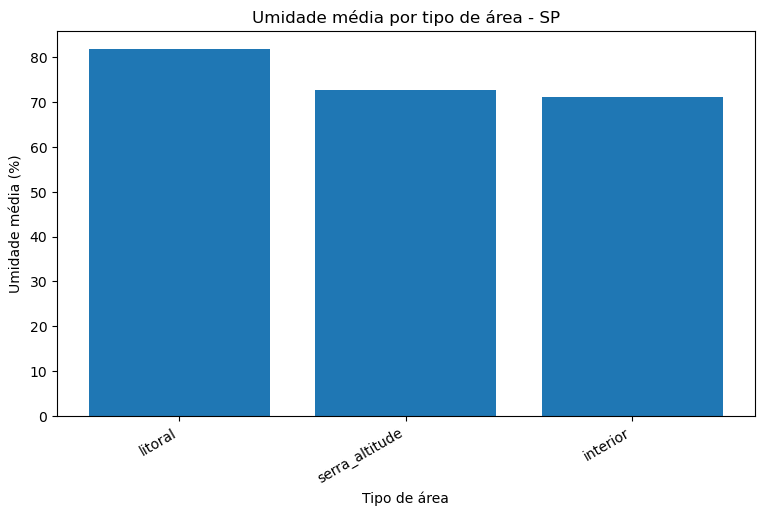

In [22]:
umidade_tipo_area = spark.sql("""
    SELECT
        tipo_area,
        ROUND(AVG(umidade), 2) AS umidade_media,
        ROUND(MIN(umidade), 2) AS umidade_minima,
        ROUND(MAX(umidade), 2) AS umidade_maxima,
        COUNT(umidade) AS registros_validos
    FROM weather_sp_geo
    WHERE umidade IS NOT NULL
    GROUP BY tipo_area
    ORDER BY umidade_media DESC
""")

umidade_tipo_area.show(truncate=False)

dados = umidade_tipo_area.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(dados["tipo_area"], dados["umidade_media"])
plt.title("Umidade média por tipo de área - SP")
plt.xlabel("Tipo de área")
plt.ylabel("Umidade média (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 22. Precipitação acumulada por tipo de área

In [ ]:
precipitacao_tipo_area = spark.sql("""
    SELECT
        tipo_area,
        ROUND(SUM(precipitacao), 2) AS precipitacao_total,
        ROUND(AVG(precipitacao), 4) AS precipitacao_media_horaria,
        COUNT(precipitacao) AS registros_validos
    FROM weather_sp_geo
    WHERE precipitacao IS NOT NULL
    GROUP BY tipo_area
    ORDER BY precipitacao_total DESC
""")

precipitacao_tipo_area.show(truncate=False)

dados = precipitacao_tipo_area.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(dados["tipo_area"], dados["precipitacao_total"])
plt.title("Precipitação acumulada por tipo de área - SP")
plt.xlabel("Tipo de área")
plt.ylabel("Precipitação acumulada (mm)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 23. Sazonalidade mensal da temperatura

+---+-----------------+------------------+------------------+-----------------+
|mes|temperatura_media|temperatura_minima|temperatura_maxima|registros_validos|
+---+-----------------+------------------+------------------+-----------------+
|1  |23.83            |-24.2             |39.9              |333035           |
|2  |23.88            |-37.7             |40.7              |302988           |
|3  |23.27            |-44.3             |37.3              |334257           |
|4  |21.71            |-48.9             |36.6              |326989           |
|5  |19.07            |-45.9             |35.1              |318371           |
|6  |18.13            |-46.1             |38.1              |306796           |
|7  |18.01            |-51.2             |33.9              |317472           |
|8  |19.2             |-51.4             |43.3              |314289           |
|9  |21.42            |-47.9             |42.2              |312267           |
|10 |22.71            |-44.9            

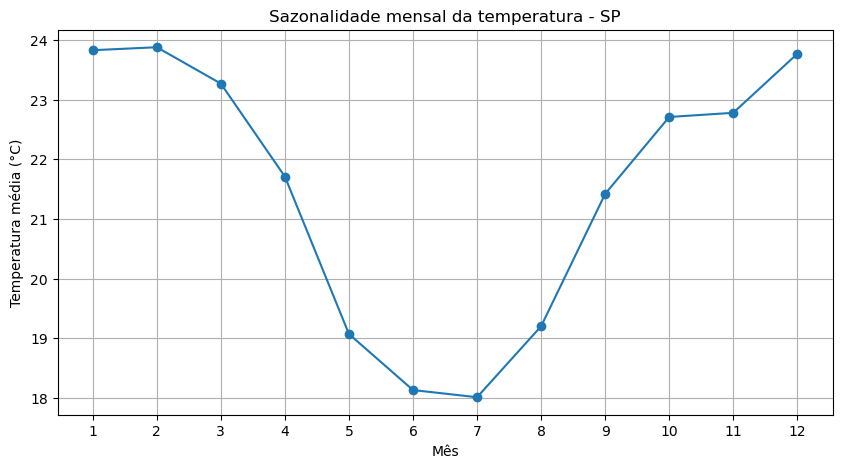

In [23]:
temp_mes = spark.sql("""
    SELECT
        mes,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(MIN(temperatura), 2) AS temperatura_minima,
        ROUND(MAX(temperatura), 2) AS temperatura_maxima,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND mes IS NOT NULL
    GROUP BY mes
    ORDER BY mes
""")

temp_mes.show(12, truncate=False)

dados = temp_mes.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(dados["mes"], dados["temperatura_media"], marker="o")
plt.title("Sazonalidade mensal da temperatura - SP")
plt.xlabel("Mês")
plt.ylabel("Temperatura média (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

## 24. Sazonalidade mensal por tipo de área

+---+--------------+-----------------+
|mes|tipo_area     |temperatura_media|
+---+--------------+-----------------+
|1  |interior      |24.56            |
|1  |litoral       |27.29            |
|1  |serra_altitude|22.01            |
|2  |interior      |24.68            |
|2  |litoral       |25.93            |
|2  |serra_altitude|21.94            |
|3  |interior      |24.12            |
|3  |litoral       |25.91            |
|3  |serra_altitude|21.15            |
|4  |interior      |22.56            |
|4  |litoral       |24.34            |
|4  |serra_altitude|19.61            |
|5  |interior      |19.72            |
|5  |litoral       |22.54            |
|5  |serra_altitude|17.35            |
|6  |interior      |18.72            |
|6  |litoral       |21.68            |
|6  |serra_altitude|16.61            |
|7  |interior      |18.67            |
|7  |litoral       |20.47            |
|7  |serra_altitude|16.37            |
|8  |interior      |19.96            |
|8  |litoral       |20.1 

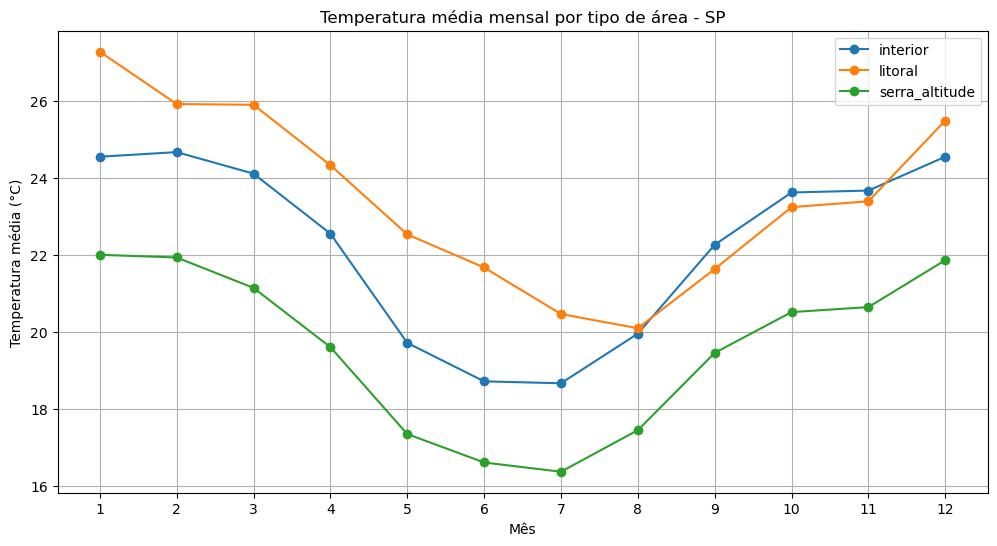

In [24]:
temp_mes_area = spark.sql("""
    SELECT
        mes,
        tipo_area,
        ROUND(AVG(temperatura), 2) AS temperatura_media
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND mes IS NOT NULL
    GROUP BY mes, tipo_area
    ORDER BY mes, tipo_area
""")

temp_mes_area.show(100, truncate=False)

dados = temp_mes_area.toPandas()
tipos_area = sorted(dados["tipo_area"].dropna().unique())

plt.figure(figsize=(12, 6))
for tipo in tipos_area:
    filtro = dados[dados["tipo_area"] == tipo]
    plt.plot(filtro["mes"], filtro["temperatura_media"], marker="o", label=tipo)

plt.title("Temperatura média mensal por tipo de área - SP")
plt.xlabel("Mês")
plt.ylabel("Temperatura média (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()
plt.show()

## 25. Ciclo diário da temperatura

+--------+-----------------+-----------------+
|hora_num|temperatura_media|registros_validos|
+--------+-----------------+-----------------+
|20      |21.52            |3858863          |
+--------+-----------------+-----------------+



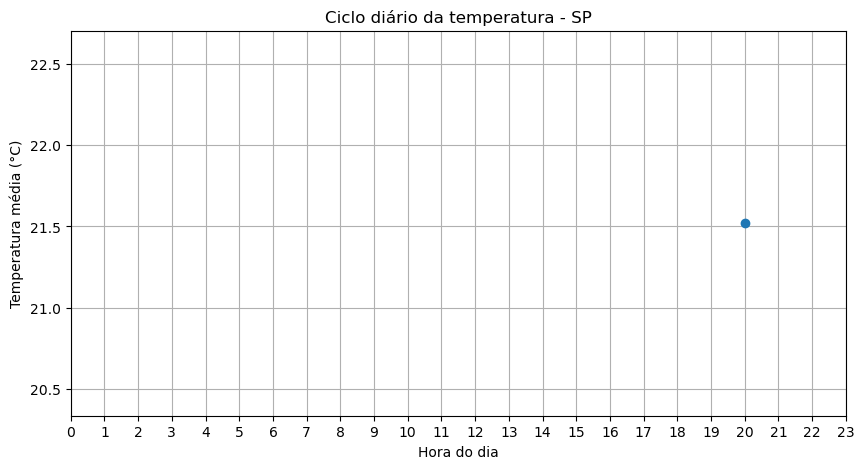

In [25]:
temp_hora = spark.sql("""
    SELECT
        hora_num,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND hora_num IS NOT NULL
    GROUP BY hora_num
    ORDER BY hora_num
""")

temp_hora.show(24, truncate=False)

dados = temp_hora.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(dados["hora_num"], dados["temperatura_media"], marker="o")
plt.title("Ciclo diário da temperatura - SP")
plt.xlabel("Hora do dia")
plt.ylabel("Temperatura média (°C)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

## 26. Ciclo diário por tipo de área

+--------+--------------+-----------------+
|hora_num|tipo_area     |temperatura_media|
+--------+--------------+-----------------+
|20      |interior      |22.3             |
|20      |litoral       |23.54            |
|20      |serra_altitude|19.62            |
+--------+--------------+-----------------+



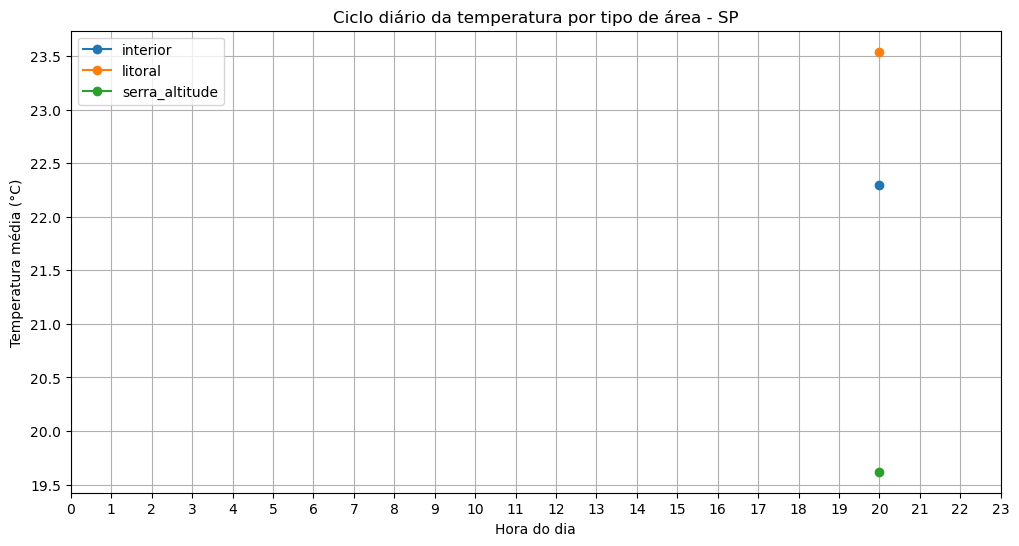

In [26]:
temp_hora_area = spark.sql("""
    SELECT
        hora_num,
        tipo_area,
        ROUND(AVG(temperatura), 2) AS temperatura_media
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND hora_num IS NOT NULL
    GROUP BY hora_num, tipo_area
    ORDER BY hora_num, tipo_area
""")

temp_hora_area.show(100, truncate=False)

dados = temp_hora_area.toPandas()
tipos_area = sorted(dados["tipo_area"].dropna().unique())

plt.figure(figsize=(12, 6))
for tipo in tipos_area:
    filtro = dados[dados["tipo_area"] == tipo]
    plt.plot(filtro["hora_num"], filtro["temperatura_media"], marker="o", label=tipo)

plt.title("Ciclo diário da temperatura por tipo de área - SP")
plt.xlabel("Hora do dia")
plt.ylabel("Temperatura média (°C)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()

## 27. Tendência anual da temperatura em São Paulo

+----+-----------------+------------------+------------------+-----------------+
|ano |temperatura_media|temperatura_minima|temperatura_maxima|registros_validos|
+----+-----------------+------------------+------------------+-----------------+
|2001|22.43            |5.8               |35.3              |2925             |
|2002|18.39            |-1.5              |38.7              |11554            |
|2003|19.68            |-0.2              |36.8              |17727            |
|2004|21.85            |2.7               |34.5              |12868            |
|2005|22.29            |5.2               |37.1              |25130            |
|2006|21.68            |2.3               |38.1              |58353            |
|2007|21.62            |-1.6              |39.7              |154197           |
|2008|21.0             |0.6               |39.2              |228760           |
|2009|21.64            |-1.0              |39.0              |208584           |
|2010|21.39            |-0.3

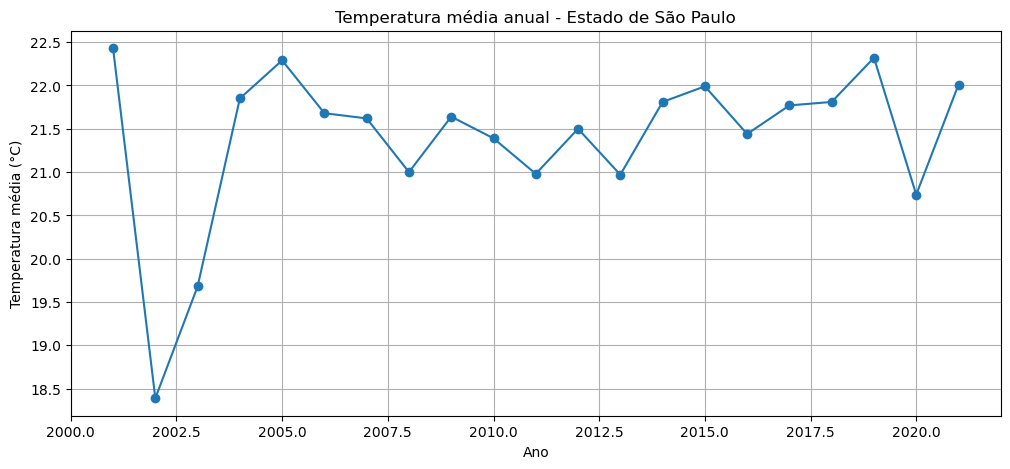

In [27]:
temp_ano_sp = spark.sql("""
    SELECT
        ano,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(MIN(temperatura), 2) AS temperatura_minima,
        ROUND(MAX(temperatura), 2) AS temperatura_maxima,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND ano IS NOT NULL
    GROUP BY ano
    ORDER BY ano
""")

temp_ano_sp.show(100, truncate=False)

dados = temp_ano_sp.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(dados["ano"], dados["temperatura_media"], marker="o")
plt.title("Temperatura média anual - Estado de São Paulo")
plt.xlabel("Ano")
plt.ylabel("Temperatura média (°C)")
plt.grid(True)
plt.show()

## 28. Tendência anual por tipo de área

+----+--------------+-----------------+
|ano |tipo_area     |temperatura_media|
+----+--------------+-----------------+
|2001|interior      |22.43            |
|2002|interior      |21.88            |
|2002|serra_altitude|14.94            |
|2003|interior      |22.24            |
|2003|serra_altitude|16.45            |
|2004|interior      |23.65            |
|2004|serra_altitude|21.17            |
|2005|interior      |22.83            |
|2005|serra_altitude|21.22            |
|2006|interior      |22.4             |
|2006|serra_altitude|20.29            |
|2007|interior      |22.56            |
|2007|serra_altitude|19.83            |
|2008|interior      |21.63            |
|2008|serra_altitude|19.47            |
|2009|interior      |22.15            |
|2009|serra_altitude|20.15            |
|2010|interior      |22.05            |
|2010|serra_altitude|19.72            |
|2011|interior      |21.7             |
|2011|serra_altitude|19.25            |
|2012|interior      |22.21            |


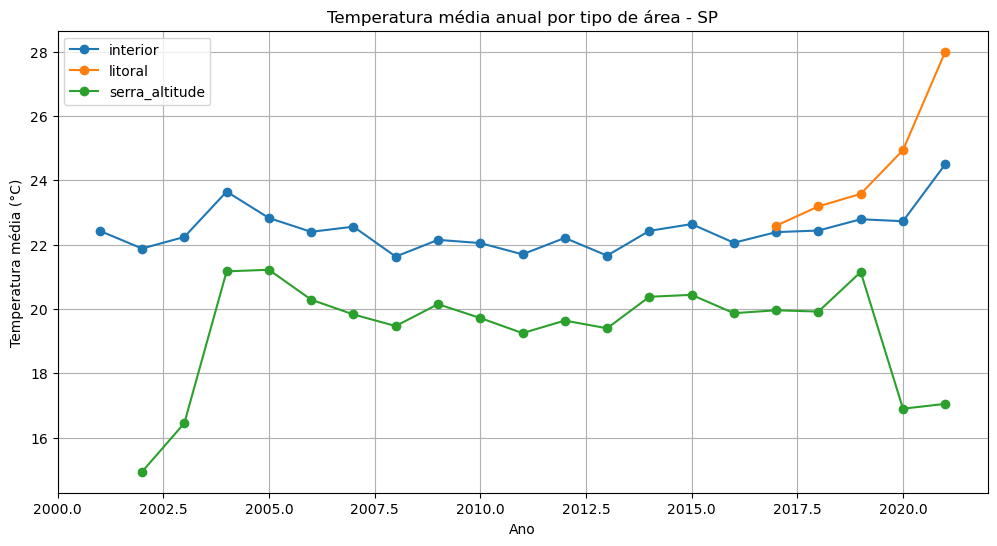

In [28]:
temp_ano_area = spark.sql("""
    SELECT
        ano,
        tipo_area,
        ROUND(AVG(temperatura), 2) AS temperatura_media
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND ano IS NOT NULL
    GROUP BY ano, tipo_area
    ORDER BY ano, tipo_area
""")

temp_ano_area.show(200, truncate=False)

dados = temp_ano_area.toPandas()
tipos_area = sorted(dados["tipo_area"].dropna().unique())

plt.figure(figsize=(12, 6))
for tipo in tipos_area:
    filtro = dados[dados["tipo_area"] == tipo]
    plt.plot(filtro["ano"], filtro["temperatura_media"], marker="o", label=tipo)

plt.title("Temperatura média anual por tipo de área - SP")
plt.xlabel("Ano")
plt.ylabel("Temperatura média (°C)")
plt.grid(True)
plt.legend()
plt.show()

## 29. Relação entre altitude e temperatura

+----------------------+------------+--------+--------------+--------------------+-----------------+-----------------+
|station               |station_code|altitude|tipo_area     |macro_regiao_sp     |temperatura_media|registros_validos|
+----------------------+------------+--------+--------------+--------------------+-----------------+-----------------+
|IGUAPE                |A712        |2.66    |interior      |centro_metropolitana|21.41            |98868            |
|IGUAPE                |A712        |2.7     |interior      |centro_metropolitana|22.17            |20424            |
|BERTIOGA              |A765        |5.0     |litoral       |leste_sudeste       |23.03            |27225            |
|SAO SEBASTIAO         |A767        |24.0    |litoral       |leste_sudeste       |24.11            |24562            |
|REGISTRO              |A766        |35.0    |interior      |centro_metropolitana|22.18            |26818            |
|VALPARAISO            |A734        |374.0   |in

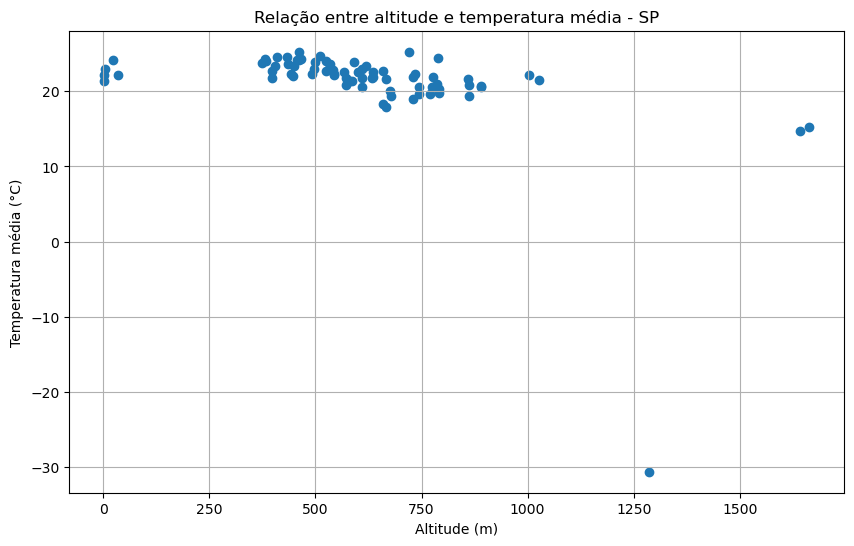

In [29]:
altitude_temperatura = spark.sql("""
    SELECT
        station,
        station_code,
        altitude,
        tipo_area,
        macro_regiao_sp,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND altitude IS NOT NULL
    GROUP BY station, station_code, altitude, tipo_area, macro_regiao_sp
    HAVING registros_validos > 1000
    ORDER BY altitude
""")

altitude_temperatura.show(300, truncate=False)

dados = altitude_temperatura.toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(dados["altitude"], dados["temperatura_media"])
plt.title("Relação entre altitude e temperatura média - SP")
plt.xlabel("Altitude (m)")
plt.ylabel("Temperatura média (°C)")
plt.grid(True)
plt.show()

## 30. Relação entre umidade e temperatura

+----------------------+------------+--------------+--------------------+-------------+-----------------+-----------------+
|station               |station_code|tipo_area     |macro_regiao_sp     |umidade_media|temperatura_media|registros_validos|
+----------------------+------------+--------------+--------------------+-------------+-----------------+-----------------+
|CRIOSFERA             |C891        |serra_altitude|sul_sudoeste        |61.64        |-30.62           |9777             |
|PRESIDENTE PRUDENTE   |A707        |interior      |oeste_noroeste      |62.94        |23.85            |141316           |
|JALES                 |A733        |interior      |oeste_noroeste      |64.04        |24.36            |110374           |
|VOTUPORANGA           |A729        |interior      |oeste_noroeste      |64.68        |24.31            |107214           |
|LINS                  |A727        |interior      |oeste_noroeste      |64.94        |23.44            |120687           |
|FRANCA 

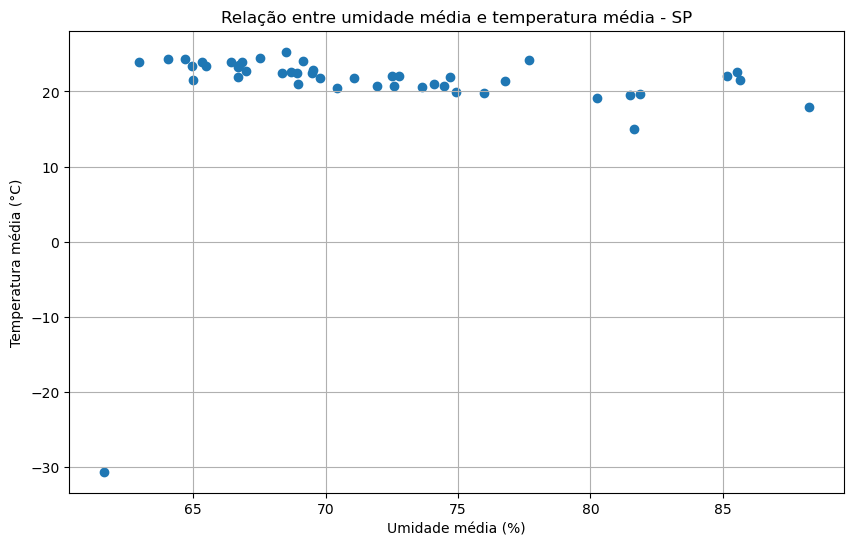

In [30]:
umidade_temperatura = spark.sql("""
    SELECT
        station,
        station_code,
        tipo_area,
        macro_regiao_sp,
        ROUND(AVG(umidade), 2) AS umidade_media,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        COUNT(temperatura) AS registros_validos
    FROM weather_sp_geo
    WHERE temperatura IS NOT NULL
      AND umidade IS NOT NULL
    GROUP BY station, station_code, tipo_area, macro_regiao_sp
    HAVING registros_validos > 1000
    ORDER BY umidade_media
""")

umidade_temperatura.show(300, truncate=False)

dados = umidade_temperatura.toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(dados["umidade_media"], dados["temperatura_media"])
plt.title("Relação entre umidade média e temperatura média - SP")
plt.xlabel("Umidade média (%)")
plt.ylabel("Temperatura média (°C)")
plt.grid(True)
plt.show()

## 31. Áreas de interesse ambiental

In [32]:
# Coordenadas aproximadas apenas para análise exploratória.

pontos_interesse = {
    "PETAR": {"lat": -24.53, "lon": -48.69},
    "Serra_do_Japi": {"lat": -23.24, "lon": -46.95},
    "Serra_da_Macaca": {"lat": -24.15, "lon": -48.05}
}

df_estacoes = spark.sql("""
    SELECT DISTINCT
        station,
        station_code,
        latitude,
        longitude,
        altitude,
        tipo_area,
        macro_regiao_sp
    FROM weather_sp_geo
    WHERE latitude IS NOT NULL
      AND longitude IS NOT NULL
""")

for nome, coords in pontos_interesse.items():
    lat_ref = coords["lat"]
    lon_ref = coords["lon"]
    coluna_dist = f"dist_{nome.lower()}_km"

    df_estacoes = df_estacoes.withColumn(
        coluna_dist,
        2 * lit(6371.0) * asin(
            sqrt(
                pow(sin((radians(col("latitude")) - radians(lit(lat_ref))) / 2), 2) +
                cos(radians(lit(lat_ref))) * cos(radians(col("latitude"))) *
                pow(sin((radians(col("longitude")) - radians(lit(lon_ref))) / 2), 2)
            )
        )
    )

df_estacoes.createOrReplaceTempView("estacoes_distancias")

df_estacoes_interesse = spark.sql("""
    SELECT
        *,
        CASE
            WHEN dist_petar_km <= dist_serra_do_japi_km AND dist_petar_km <= dist_serra_da_macaca_km AND dist_petar_km <= 80 THEN 'PETAR'
            WHEN dist_serra_do_japi_km <= dist_petar_km AND dist_serra_do_japi_km <= dist_serra_da_macaca_km AND dist_serra_do_japi_km <= 80 THEN 'Serra do Japi'
            WHEN dist_serra_da_macaca_km <= dist_petar_km AND dist_serra_da_macaca_km <= dist_serra_do_japi_km AND dist_serra_da_macaca_km <= 80 THEN 'Serra da Macaca'
            ELSE 'Outra região'
        END AS area_interesse
    FROM estacoes_distancias
""")

df_estacoes_interesse.createOrReplaceTempView("estacoes_interesse")

spark.sql("""
    SELECT
        area_interesse,
        COUNT(DISTINCT station_code) AS total_estacoes
    FROM estacoes_interesse
    GROUP BY area_interesse
    ORDER BY total_estacoes DESC
""").show(truncate=False)

+---------------+--------------+
|area_interesse |total_estacoes|
+---------------+--------------+
|Outra região   |35            |
|Serra do Japi  |5             |
|Serra da Macaca|3             |
|PETAR          |2             |
+---------------+--------------+



## 32. Temperatura e umidade nas áreas de interesse

+---------------+--------------+-----------------+-------------+------------------+
|area_interesse |total_estacoes|temperatura_media|umidade_media|precipitacao_total|
+---------------+--------------+-----------------+-------------+------------------+
|PETAR          |2             |19.19            |79.95        |86087.8           |
|Serra do Japi  |5             |20.38            |73.88        |151079.2          |
|Serra da Macaca|3             |20.46            |83.2         |69842.4           |
|Outra região   |35            |22.0             |70.01        |1051185.6         |
+---------------+--------------+-----------------+-------------+------------------+



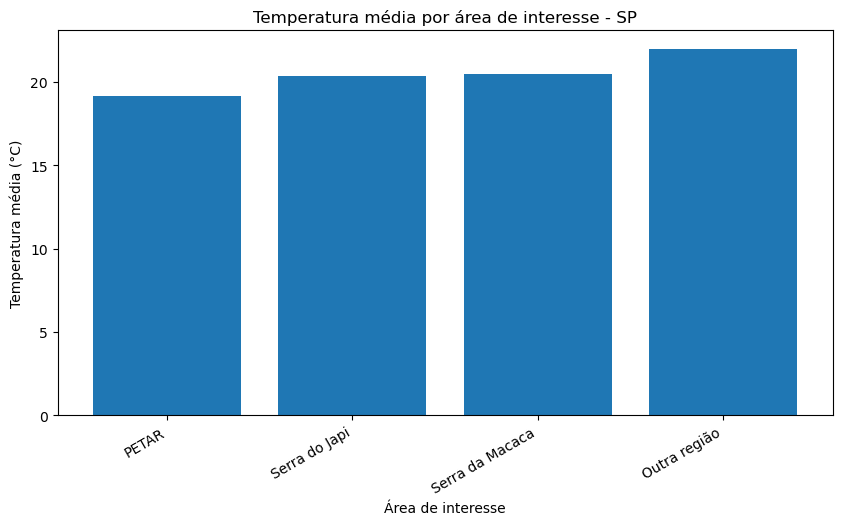

In [33]:
df_sp_interesse = df_sp_geo.join(
    df_estacoes_interesse.select("station_code", "area_interesse"),
    on="station_code",
    how="left"
)

df_sp_interesse.createOrReplaceTempView("weather_sp_interesse")

area_interesse_clima = spark.sql("""
    SELECT
        area_interesse,
        COUNT(DISTINCT station_code) AS total_estacoes,
        ROUND(AVG(temperatura), 2) AS temperatura_media,
        ROUND(AVG(umidade), 2) AS umidade_media,
        ROUND(SUM(precipitacao), 2) AS precipitacao_total
    FROM weather_sp_interesse
    WHERE area_interesse IS NOT NULL
    GROUP BY area_interesse
    ORDER BY temperatura_media
""")

area_interesse_clima.show(truncate=False)

dados = area_interesse_clima.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(dados["area_interesse"], dados["temperatura_media"])
plt.title("Temperatura média por área de interesse - SP")
plt.xlabel("Área de interesse")
plt.ylabel("Temperatura média (°C)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 33. Correlação com a temperatura

In [34]:
variaveis_correlacao = [
    "latitude",
    "longitude",
    "altitude",
    "umidade",
    "umidade_maxima",
    "umidade_minima",
    "pressao",
    "pressao_maxima",
    "pressao_minima",
    "precipitacao",
    "radiacao",
    "velocidade_vento",
    "rajada_vento",
    "direcao_vento",
    "mes",
    "hora_num"
]

variaveis_correlacao = [c for c in variaveis_correlacao if c in df_sp_geo.columns]

correlacoes = []

for c in variaveis_correlacao:
    try:
        valor = df_sp_geo.select(corr(col(c), col("temperatura"))).collect()[0][0]
        if valor is not None:
            correlacoes.append((c, round(valor, 4)))
    except Exception as erro:
        print(f"Não foi possível calcular correlação para {c}: {erro}")

correlacoes_ordenadas = sorted(correlacoes, key=lambda x: abs(x[1]), reverse=True)

print(f"{'Variável':<30} {'Correlação com temperatura':>25}")
print("-" * 60)

for nome, valor in correlacoes_ordenadas:
    print(f"{nome:<30} {valor:>25.4f}")

Não foi possível calcular correlação para latitude: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para longitude: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para altitude: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para umidade: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para umidade_maxima: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para umidade_minima: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para pressao: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or str, got float.
Não foi possível calcular correlação para pressao_maxima: [NOT_COLUMN_OR_STR] Argument `col` should be a Column or

## 34. Criação de base agregada diária para apoiar modelagem

In [35]:
base_diaria_sp = spark.sql("""
    SELECT
        station,
        station_code,
        data_formatada,
        ano,
        mes,
        latitude,
        longitude,
        altitude,
        macro_regiao_sp,
        tipo_area,
        faixa_altitude,
        ROUND(AVG(temperatura), 2) AS temp_media_dia,
        ROUND(MIN(temperatura), 2) AS temp_min_dia,
        ROUND(MAX(temperatura), 2) AS temp_max_dia,
        ROUND(AVG(umidade), 2) AS umidade_media_dia,
        ROUND(SUM(precipitacao), 2) AS precipitacao_total_dia,
        ROUND(AVG(pressao), 2) AS pressao_media_dia,
        ROUND(AVG(radiacao), 2) AS radiacao_media_dia,
        ROUND(AVG(velocidade_vento), 2) AS vento_medio_dia,
        COUNT(temperatura) AS medicoes_temp_validas
    FROM weather_sp_geo
    WHERE data_formatada IS NOT NULL
    GROUP BY
        station,
        station_code,
        data_formatada,
        ano,
        mes,
        latitude,
        longitude,
        altitude,
        macro_regiao_sp,
        tipo_area,
        faixa_altitude
    ORDER BY station_code, data_formatada
""")

base_diaria_sp.createOrReplaceTempView("base_diaria_sp")

base_diaria_sp.show(50, truncate=False)

+-------------------+------------+--------------+----+---+------------+------------+--------+---------------+--------------+--------------+--------------+------------+------------+-----------------+----------------------+-----------------+------------------+---------------+---------------------+
|station            |station_code|data_formatada|ano |mes|latitude    |longitude   |altitude|macro_regiao_sp|tipo_area     |faixa_altitude|temp_media_dia|temp_min_dia|temp_max_dia|umidade_media_dia|precipitacao_total_dia|pressao_media_dia|radiacao_media_dia|vento_medio_dia|medicoes_temp_validas|
+-------------------+------------+--------------+----+---+------------+------------+--------+---------------+--------------+--------------+--------------+------------+------------+-----------------+----------------------+-----------------+------------------+---------------+---------------------+
|SAO PAULO - MIRANTE|A701        |2006-07-25    |2006|7  |-23.48333333|-46.61666666|792.06  |nordeste_vale  |

## 35. Salvamento das bases de EDA

In [ ]:
eda_geo_path = "/home/jovyan/work/data/processed/weather_sp_eda_geo"
base_diaria_path = "/home/jovyan/work/data/processed/weather_sp_base_diaria"

df_sp_geo.write.mode("overwrite").parquet(eda_geo_path)
base_diaria_sp.write.mode("overwrite").parquet(base_diaria_path)

print(f"Base EDA geográfica salva em: {eda_geo_path}")
print(f"Base diária salva em: {base_diaria_path}")

## 36. Principais insights esperados para apresentação

Depois de executar este notebook, você pode organizar a apresentação em torno destas perguntas:

1. Quantas estações meteorológicas existem em São Paulo e qual o período analisado?
2. Quais variáveis possuem mais valores ausentes?
3. Quais regiões de SP apresentam maior ou menor temperatura média?
4. A altitude influencia a temperatura média?
5. Litoral, serra, interior e áreas urbanas apresentam diferenças claras?
6. A umidade é maior em regiões litorâneas ou de serra?
7. Como a temperatura muda ao longo dos meses?
8. Como a temperatura muda ao longo das horas do dia?
9. Quais estações são historicamente mais frias e mais quentes?
10. Que variáveis parecem mais relacionadas à temperatura?

Esses pontos conectam a EDA diretamente com a modelagem, pois mostram que a previsão de temperatura deve considerar:

- sazonalidade mensal;
- ciclo diário;
- altitude;
- latitude e longitude;
- umidade;
- pressão;
- precipitação;
- diferenças regionais dentro do estado.

## 37. Conclusão da EDA

Esta EDA mostrou que o dataset possui potencial para análises além da simples previsão de temperatura.

A base de São Paulo permite explorar diferenças espaciais importantes entre litoral, serra, interior e áreas urbanas.

A presença de latitude, longitude e altitude permite enriquecer a análise com uma dimensão geográfica.

Além disso, os padrões mensais e horários indicam forte componente temporal, justificando a criação de features de sazonalidade e bases específicas para previsão futura.

Próximos passos:

1. usar a base diária salva neste notebook;
2. criar o alvo `temperatura_amanha`;
3. criar o alvo `temperatura_media_proximos_7_dias`;
4. treinar e comparar Linear Regression, Random Forest e Redes Neurais.